# Hugging Face 모델을 Colab GPU에서 추론하기

**목표:** Hugging Face CLI로 받은 모델을 Transformers로 불러오고, GPU에서 이미지 한 장의 분류 결과를 확인합니다.
이 단계는 원래 모델의 1,000개 ImageNet 분류를 사용합니다. 다음 실습에서 우리 데이터의 5개 클래스로 바꿉니다.

## 1. 라이브러리와 GPU 확인

이 노트북은 **Colab CLI로 연결한 GPU 세션**에서 실행합니다. Codespaces는 파일 작성·업로드에 사용합니다.
`00_hf_download_and_data.ipynb`에서 받은 모델 파일과 기존 `data/prepared`의 데이터를 먼저 업로드하세요.
GPU가 없으면 여기서 멈춥니다. 설치와 세션 연결 순서는 이 폴더의 README를 따릅니다.

In [ ]:
TRAINING_ALLOWED = False
import os
import sys
import json
import hashlib
import random
from pathlib import Path
from importlib.metadata import version

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython import get_ipython
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
if not torch.cuda.is_available():
    raise RuntimeError("GPU가 없습니다. Colab CLI GPU 세션으로 실행하세요.")
device = torch.device("cuda")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Python:", sys.executable)
print("GPU:", torch.cuda.get_device_name(0))
print({name: version(name) for name in ("torch", "transformers", "huggingface-hub")})

Python: /usr/bin/python3
GPU: Tesla T4
{'torch': '2.8.0+cu126', 'transformers': '4.57.6', 'huggingface-hub': '0.36.0'}


In [ ]:
candidates = [Path.cwd(), *Path.cwd().parents, Path("/content/vision-ai")]
ROOT = next((p for p in candidates if (p / ".vision-lab-root").is_file()), None)
if ROOT is None:
    raise FileNotFoundError(".vision-lab-root와 실습 파일을 먼저 업로드하세요.")
MODEL_ID = 'facebook/deit-tiny-patch16-224'
MODEL_REVISION = 'b3428f18dcc7b543470d07f14b4a4157815d1880'
MODEL_DIR = ROOT / "hf_colab_gpu/models/deit-tiny"
DATA_DIR = ROOT / "data/prepared"
OUTPUT_DIR = ROOT / "hf_colab_gpu/results/gpu"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

download_manifest = json.loads((MODEL_DIR / "download_manifest.json").read_text())
assert download_manifest["model_id"] == MODEL_ID
assert download_manifest["revision"] == MODEL_REVISION
for name in ("config.json", "preprocessor_config.json", "pytorch_model.bin"):
    assert sha256_file(MODEL_DIR / name) == download_manifest["files"][name], name
print("HF CLI 다운로드 파일 확인:", MODEL_ID, MODEL_REVISION[:12])

HF CLI 다운로드 파일 확인: facebook/deit-tiny-patch16-224 b3428f18dcc7


## 2. 데이터와 분할 확인

CIFAR-100에서 bottle·bowl·can·cup·plate를 골랐습니다. 원본은 32×32 이미지이며 모델 입력 크기로 확대합니다.
실제 작업대 사진과는 차이가 있으므로 이 결과를 현장 정확도로 해석하지 않습니다.
학습 500장, 검증 100장, 최종 평가 200장으로 나눴고, 학습 중 모델 선택에는 검증 데이터만 사용합니다.

In [ ]:
manifest_file = DATA_DIR / "manifest.json"
manifest = json.loads(manifest_file.read_text(encoding="utf-8"))
classes = manifest["classes"]
if len(classes) < 2 or len(set(classes)) != len(classes):
    raise ValueError("클래스 목록을 확인하세요.")
identity = {k: manifest[k] for k in ("classes", "splits", "seed", "preprocess")}
fingerprint = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()
assert fingerprint == manifest["dataset_sha256"]
splits, seen_ids = {}, set()
for split in ("train", "validation", "test"):
    record = manifest["splits"][split]
    assert record["file"] == f"{split}.npz"
    file = DATA_DIR / record["file"]
    assert sha256_file(file) == record["sha256"], split
    with np.load(file, allow_pickle=False) as stored:
        images, labels, ids = stored["images"], stored["labels"], stored["ids"]
    assert images.dtype == np.uint8 and images.ndim == 4 and images.shape[-1] == 3
    assert labels.ndim == 1 and np.issubdtype(labels.dtype, np.integer)
    assert len(images) == len(labels) == len(ids) == record["count"] > 0
    assert labels.min() >= 0 and labels.max() < len(classes)
    assert len(set(ids)) == len(ids) and not seen_ids.intersection(ids)
    seen_ids.update(ids)
    splits[split] = {"images": images, "labels": labels, "ids": ids}
    print(split, len(labels), "images")
print("클래스 순서:", classes)

train 500 images
validation 100 images
test 200 images
클래스 순서: ['bottle', 'bowl', 'can', 'cup', 'plate']


## 3. Transformers로 모델 불러오기

`AutoImageProcessor`가 크기 조정·정규화를 맡고, `AutoModelForImageClassification`이 사전학습 모델을 만듭니다.
`hf download`로 받은 로컬 파일만 사용하므로 이 단계에서 추가 다운로드는 하지 않습니다.
원본 가중치는 `.bin`이며 `weights_only=True`로 읽습니다. 실습 후 저장할 모델은 Safetensors 형식입니다.

In [ ]:
processor = AutoImageProcessor.from_pretrained(
    MODEL_DIR, local_files_only=True, use_fast=False,
)
model = AutoModelForImageClassification.from_pretrained(
    MODEL_DIR, local_files_only=True, use_safetensors=False, weights_only=True,
    attn_implementation="eager",
).to(device)
print(type(model).__name__, "· 원래 분류 수:", model.config.num_labels)
print("전체 파라미터:", f"{sum(p.numel() for p in model.parameters()):,}")

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


ViTForImageClassification · 원래 분류 수: 1000
전체 파라미터: 5,717,416


## 4. 이미지 한 장을 GPU에서 추론하기

정답이 cup인 예시를 선택합니다. 입력 사진이 작고 원래 모델의 분류 목록도 다르므로,
이 한 장의 상위 예측만으로 실습 데이터 전체의 정확도를 판단하지 않습니다.

In [ ]:
target_class = classes.index("cup") if "cup" in classes else 0
image_index = int(np.flatnonzero(splits["test"]["labels"] == target_class)[0])
image = Image.fromarray(splits["test"]["images"][image_index]).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)
model.eval()
with torch.inference_mode():
    probabilities = model(**inputs).logits.softmax(dim=-1)[0]
values, indices = probabilities.topk(5)
predictions = [
    {"label": model.config.id2label[int(index)], "probability": float(value)}
    for value, index in zip(values.cpu(), indices.cpu())
]
print("실습 데이터 정답:", classes[target_class])
for item in predictions:
    print(f"{item['probability']:6.2%}  {item['label']}")

실습 데이터 정답: cup
 5.01%  face powder
 4.10%  eggnog
 1.87%  frying pan, frypan, skillet
 1.73%  waffle iron
 1.39%  potter's wheel


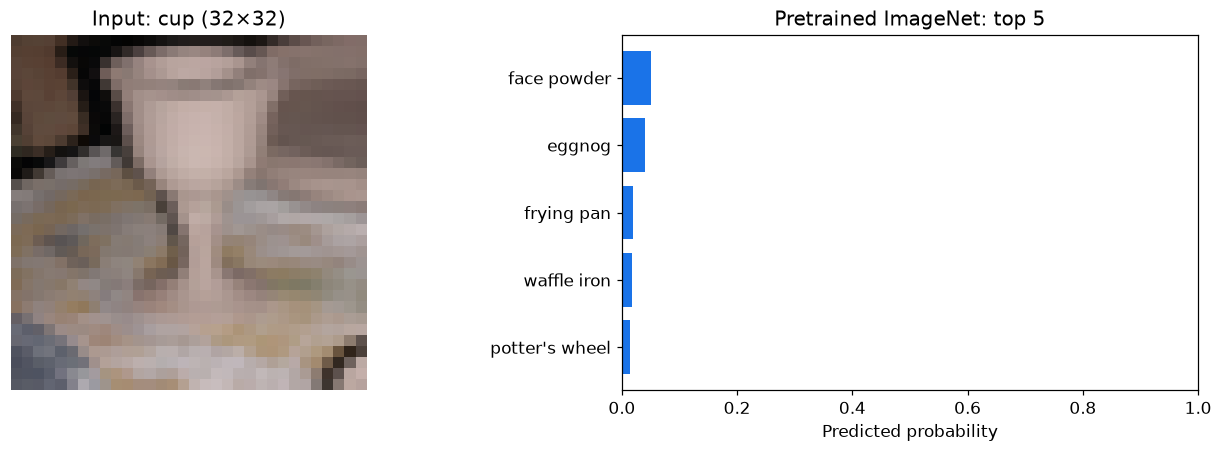

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].imshow(image)
axes[0].set_title(f"Input: {classes[target_class]} (32×32)")
axes[0].axis("off")
labels = [item["label"].split(",")[0] for item in predictions]
axes[1].barh(labels[::-1], [p["probability"] for p in predictions][::-1], color="#1a73e8")
axes[1].set_xlabel("Predicted probability")
axes[1].set_xlim(0, 1)
axes[1].set_title("Pretrained ImageNet: top 5")
fig.savefig(OUTPUT_DIR / "pretrained_top5.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 실행 기록 확인

예측 결과와 실제 GPU 이름을 저장합니다. 이 결과는 원래 모델을 불러오는 데 성공했는지 확인하는 기록입니다.
다음 노트북에서는 분류 헤드만 학습한 기준 모델과, 마지막 블록까지 파인튜닝한 모델을 비교합니다.

In [ ]:
inference_report = {
    "status": "completed", "platform": "gpu", "device": torch.cuda.get_device_name(0),
    "model_id": MODEL_ID, "model_revision": MODEL_REVISION,
    "download_manifest_sha256": sha256_file(MODEL_DIR / "download_manifest.json"),
    "dataset_sha256": manifest["dataset_sha256"],
    "sample_id": str(splits["test"]["ids"][image_index]),
    "ground_truth": classes[target_class], "top5": predictions,
    "versions": {name: version(name) for name in ("torch", "transformers", "huggingface-hub")},
}
(OUTPUT_DIR / "inference_report.json").write_text(
    json.dumps(inference_report, ensure_ascii=False, indent=2), encoding="utf-8",
)
print("HF_GPU_INFERENCE_COMPLETE", OUTPUT_DIR / "inference_report.json")

HF_GPU_INFERENCE_COMPLETE /content/vision-ai/hf_colab_gpu/results/gpu/inference_report.json
